Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

Step 1: Load the dataset and explore its structure.


In [ ]:

datafream = pd.read_excel('/content/Students_Grading_Dataset (1).xlsx')




Exploring the Dataset Overview

In [ ]:
 # Display basic dataset information before cleaning
print("\n[INFO] Initial Dataset Information:")
datafream.head(5)


[INFO] Initial Dataset Information:


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


## From my initial observation of a sample of the data, I found the following:

Missing Data:

Some students have missing values for Attendance, Quizzes_Avg, and Participation_Score (like S1005, S1001, and S1020).
Parent_Education_Level is also missing for S1006 and S1027.
Inconsistent Gender Labels:

Omar Williams (S1000) is marked as Female, but "Omar" is generally a male name.
Maria Brown (S1001) is labeled as Male, even though "Maria" is typically a female name. and others
Grade and Total_Score Discrepancies:

S1001 has a Total_Score of 50.64 but still got an A — that doesn’t seem right.
S1006 has a Total_Score of 83.21 but received an F — this definitely looks off.
Duplicate Names:

Multiple students have the same First and Last Names (e.g., Omar Williams, Ahmed Jones), which could lead to confusion if Student_ID is not used properly.
Unrealistic Sleep Patterns:

Some students have very low sleep hours, like S1007 with 4.3 hours and S1028 with 4.0 hours.
Possible Grade Calculation Errors:

Some students got high scores in assignments, quizzes, and projects but still have lower grades than expected. We should check the grading formula.

In [ ]:
datafream.shape

(5000, 23)

In [ ]:
print(f'Number of rows: {datafream.shape[0]}')
print(f'Number of columns: {datafream.shape[1]}')

Number of rows: 5000
Number of columns: 23


In [ ]:
datafream.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              4484 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             4483 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

from previous output we can see that:

having null values

In [ ]:
datafream.describe()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,4484.000000,5000.000000,5000.000000,4483.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,14.372446,17.213209,17.238744,14.411799,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,63.265000,55.457500,54.667500,62.090000,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.725000,70.510000,69.735000,74.810000,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,87.472500,84.970000,84.500000,86.970000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


In [ ]:
 # Handling missing values
print("\n[INFO] Missing values before handling:")
datafream.isnull().sum()


[INFO] Missing values before handling:


,0
Student_ID,0
First_Name,0
Last_Name,0
Email,0
Gender,0
Age,0
Department,0
Attendance (%),516
Midterm_Score,0
Final_Score,0


There are missing values in the Parent_Education_Level column because our data includes five categories:
No Education
High School
Bachelor's
Master's
PhD
It seems that when entering the data, the field was left blank if there was no parent education.
This resulted in many missing values in the Parent_Education_Level feature.

In [ ]:
datafream.head(5)

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [ ]:
# Fill missing values in 'Parent_Education_Level' with 'No Education'
datafream['Parent_Education_Level'].fillna('No Education', inplace=True)
# droup missing values in numeric columns
datafream.dropna(subset=['Attendance (%)', 'Assignments_Avg'], inplace=True)

<ipython-input-142-2a4bbaab3861>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datafream['Parent_Education_Level'].fillna('No Education', inplace=True)


Handling Missing Values¶
From our data analysis, we found:

Parent_Education_Level: Missing values occur when no parent education was reported. We’ll add a new category like "No Education" to represent them.

Attendance (%) and Assignments_Avg: Given the high percentage of missing values (around 20% of total rows), the best approach is to delete these rows, which won’t significantly impact data integrity.

In [ ]:
datafream.isnull().sum()

,0
Student_ID,0
First_Name,0
Last_Name,0
Email,0
Gender,0
Age,0
Department,0
Attendance (%),0
Midterm_Score,0
Final_Score,0


Now, after correctly handling the missing values based on the columns where the data was missing—namely, the parents’ education level, attendance, and average project scores—we observe that after using the function for handling missing values, the number of missing values is now zero.


In [ ]:
print("\n[INFO] Missing values after handling:")
datafream.head(5000)


[INFO] Missing values after handling:


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
6,S1006,Ahmed,Jones,student6@university.com,Male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,No Education,Low,5,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4990,S5990,Ali,Johnson,student4990@university.com,Male,24,CS,80.53,87.83,43.70,...,65.16,81.18,F,15.2,No,Yes,No Education,Low,7,7.1
4993,S5993,Ali,Johnson,student4993@university.com,Female,22,Business,99.21,60.16,59.18,...,69.56,85.86,A,16.9,No,Yes,No Education,Low,2,7.8
4997,S5997,John,Brown,student4997@university.com,Female,24,CS,87.54,63.55,64.21,...,82.65,54.25,A,24.8,Yes,No,High School,Medium,4,6.3
4998,S5998,Sara,Davis,student4998@university.com,Male,23,CS,92.56,79.79,94.28,...,94.29,55.84,A,16.1,Yes,Yes,Bachelor's,Low,1,8.4


In [ ]:
# Function to clean text data
def clean_text(text):
    return re.sub(r'[^A-Za-z0-9أ-ي\s]', '', text) if isinstance(text, str) else text

In [ ]:
# Apply text cleaning to all text columns
for col in datafream.select_dtypes(include=['object']).columns:
    datafream[col] = datafream[col].apply(clean_text)

# Display the dataframe after cleaning
datafream.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0universitycom,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
2,S1002,Ahmed,Jones,student2universitycom,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Masters,Low,6,6.2
3,S1003,Omar,Williams,student3universitycom,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4universitycom,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
6,S1006,Ahmed,Jones,student6universitycom,Male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,No Education,Low,5,6.4



The clean_text function cleans text by removing any unwanted characters or symbols, retaining only English letters, numbers, Arabic letters, and spaces. If the input is not a string, the function returns the value unchanged.

The code consists of two parts: the `gender_map` dictionary and the `clean_text` function.

The `gender_map` standardizes gender representations by mapping Arabic terms like `'ذكر'` (male) and `'أنثى'` (female) to English equivalents, including abbreviations. This ensures consistent gender data for analysis.
This method standardizes and corrects the **Gender** column by:  

**Standardizing Labels:** Converts all gender values to lowercase, removes extra spaces, and replaces variations (e.g., `"M" → "male"`).  
 **Correcting Gender by First Name:** If a student's **first name** is in a predefined male/female list but their gender is incorrect, it is corrected.  

 Ensures **data consistency**, reduces errors, and improves **data quality** for analysis.

In [ ]:
# Standardizing gender labels
gender_map = {
    'ذكر': 'male', 'أنثى': 'female', 'm': 'male', 'f': 'female',
    'female': 'female', 'male': 'male', 'M': 'male', 'F': 'female',
    'MALE': 'male', 'FEMALE': 'female'
}

# Ensure 'Gender' column exists before applying corrections
if 'Gender' in datafream.columns:
    datafream['Gender'] = datafream['Gender'].astype(str).str.strip().str.lower().replace(gender_map)
else:
    print("\n[WARNING] Column 'Gender' not found in dataset.")

# Correct gender based on common first names
male_names = {"Omar", "Ahmed", "Mohamed", "Ali", "Hassan", "John", "Michael"}
female_names = {"Maria", "Sarah", "Fatima", "Aisha", "Sophia", "Emily"}

def correct_gender(row):
    if pd.isnull(row["Gender"]) or row["Gender"] not in {"male", "female"}:
        return row["Gender"]  # Skip correction if gender is missing or invalid

    if "First_Name" in row and pd.notnull(row["First_Name"]):
        first_name = str(row["First_Name"]).strip().title()  # Normalize name formatting

        if first_name in male_names and row["Gender"] == "female":
            return "male"
        elif first_name in female_names and row["Gender"] == "male":
            return "female"

    return row["Gender"]

if "First_Name" in datafream.columns:
    datafream["Gender"] = datafream.apply(correct_gender, axis=1)
else:
    print("\n[WARNING] Column 'First_Name' not found in dataset.")





In [ ]:
# Display the cleaned data
datafream.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0universitycom,male,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
2,S1002,Ahmed,Jones,student2universitycom,male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Masters,Low,6,6.2
3,S1003,Omar,Williams,student3universitycom,male,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4universitycom,male,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
6,S1006,Ahmed,Jones,student6universitycom,male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,No Education,Low,5,6.4


**CHECK FOR DUPLICATES**

In [ ]:
# Find duplicate rows (considering all columns)
duplicates = datafream[datafream.duplicated()] # Changed 'datafream' to 'dataframe'

# Print the number of duplicate rows if any
print(f"Number of duplicate rows: {duplicates.shape[0]}")

# Display duplicate rows (optional)
duplicates

Number of duplicate rows: 0


,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night


** Remove duplicate rows**

In [ ]:
# Remove duplicate rows while keeping the first occurrence
df = datafream.drop_duplicates()

# Confirm the number of rows after removing duplicates
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 4018


By using the duplication method, we discovered that there are no duplicate values in the data. Additionally, we handled any duplicates by removing them if found, as shown in the following print statement.

In [ ]:
datafream.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0universitycom,male,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
2,S1002,Ahmed,Jones,student2universitycom,male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Masters,Low,6,6.2
3,S1003,Omar,Williams,student3universitycom,male,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4universitycom,male,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
6,S1006,Ahmed,Jones,student6universitycom,male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,No Education,Low,5,6.4


Here, after resolving the inconsistency issue in the gender column using a previous method, we now check whether the method worked correctly by printing four columns: first name, last name, and gender before and after the modification.And we found that this method worked correctly because it returned zero, indicating that there are no more inconsistencies.

In [ ]:
# Select only text (string) columns
text_columns = datafream.select_dtypes(include=['object']).columns

# Strip extra spaces from text columns
datafream[text_columns] = datafream[text_columns].apply(lambda x: x.str.strip())

# Verify that text data is cleaned
datafream.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0universitycom,male,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
2,S1002,Ahmed,Jones,student2universitycom,male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Masters,Low,6,6.2
3,S1003,Omar,Williams,student3universitycom,male,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4universitycom,male,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1
6,S1006,Ahmed,Jones,student6universitycom,male,24,Business,57.60,66.26,89.07,...,93.65,83.21,F,21.3,No,Yes,No Education,Low,5,6.4


** Clean Text Data (Remove Extra Spaces)**





In [ ]:
# Function to assign the correct grade based on total score
def assign_correct_grade(score):
    if pd.isnull(score):  # Handle missing scores
        return None
    try:
        score = float(score)  # Ensure score is numeric
        if 90 <= score <= 100:
            return "A"
        elif 80 <= score <= 89:
            return "B"
        elif 70 <= score <= 79:
            return "C"
        elif 60 <= score <= 69:
            return "D"
        else:
            return "F"
    except ValueError:
        return None  # Handle non-numeric values gracefully

# Ensure 'Total_Score' column exists before applying corrections
if "Total_Score" in datafream.columns:
    datafream["Corrected_Grade"] = datafream["Total_Score"].apply(assign_correct_grade)

    # Identify records with incorrect grades
    incorrect_grades = datafream[datafream["Grade"] != datafream["Corrected_Grade"]]

    if not incorrect_grades.empty:
        print("\n[INFO] Students with Incorrect Grades:")
        print(incorrect_grades[["Student_ID", "Total_Score", "Grade", "Corrected_Grade"]])

    # Correct the 'Grade' column
    datafream["Grade"] = datafream["Corrected_Grade"]
else:
    print("\n[WARNING] Column 'Total_Score' not found in dataset.")



[INFO] Students with Incorrect Grades:
     Student_ID  Total_Score Grade Corrected_Grade
2         S1002        70.30     D               C
3         S1003        61.63     A               D
4         S1004        66.13     F               D
6         S1006        83.21     F               B
7         S1007        81.93     F               B
...         ...          ...   ...             ...
4990      S5990        81.18     F               B
4993      S5993        85.86     A               B
4997      S5997        54.25     A               F
4998      S5998        55.84     A               F
4999      S5999        77.86     F               C

[3262 rows x 4 columns]


  
This method ensures **grade accuracy** by:  

1. **Assigning Correct Grades:** Converts scores to numeric values and assigns grades (`A-F`) based on predefined ranges.  
2. **Handling Errors:** Deals with missing or non-numeric values gracefully.  
3. **Identifying Incorrect Grades:** Compares assigned grades with existing ones and lists discrepancies.  

 Improves **data consistency**, fixes grading errors, and enhances dataset reliability.

In [ ]:
datafream.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Corrected_Grade
0,S1000,Omar,Williams,student0universitycom,male,22,Engineering,52.29,55.03,57.82,...,56.09,F,6.2,No,Yes,High School,Medium,5,4.7,F
2,S1002,Ahmed,Jones,student2universitycom,male,24,Business,57.19,67.05,93.68,...,70.30,C,20.7,No,Yes,Masters,Low,6,6.2,C
3,S1003,Omar,Williams,student3universitycom,male,24,Mathematics,95.15,47.79,80.63,...,61.63,D,24.8,Yes,Yes,High School,High,3,6.7,D
4,S1004,John,Smith,student4universitycom,male,23,CS,54.18,46.59,78.89,...,66.13,D,15.4,Yes,Yes,High School,High,2,7.1,D
6,S1006,Ahmed,Jones,student6universitycom,male,24,Business,57.60,66.26,89.07,...,83.21,B,21.3,No,Yes,No Education,Low,5,6.4,B


Step :Analyzing the Distribution of Students' Sleep Hours and Detecting Outliers Using IQR

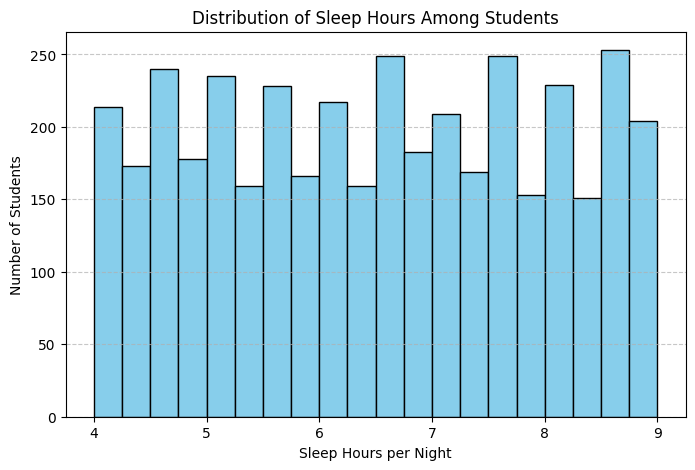

Empty DataFrame
Columns: [Student_ID, First_Name, Last_Name, Sleep_Hours_per_Night]
Index: []


In [ ]:

# Analyze outliers in sleep hours
plt.figure(figsize=(8, 5))
plt.hist(datafream["Sleep_Hours_per_Night"], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Sleep Hours per Night")
plt.ylabel("Number of Students")
plt.title("Distribution of Sleep Hours Among Students")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate interquartile range (IQR) to detect outliers
Q1 = datafream["Sleep_Hours_per_Night"].quantile(0.25)
Q3 = datafream["Sleep_Hours_per_Night"].quantile(0.75)
IQR = Q3 - Q1

# تحديد الحدود للقيم الشاذة
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# استخراج القيم الشاذة
outliers = datafream[(datafream["Sleep_Hours_per_Night"] < lower_bound) | (datafream["Sleep_Hours_per_Night"] > upper_bound)]

# عرض القيم الشاذة
print(outliers[["Student_ID", "First_Name", "Last_Name", "Sleep_Hours_per_Night"]])

This is the distribution of sleep hours among students. To identify outliers, I will use the outlier detection method based on the IQR (Interquartile Range).  

There are no outliers in sleep hours based on the IQR method, which means all data falls within the normal range. However, some students may have unhealthy low sleep hours, even though they are not statistically classified as outliers.
I don’t need to handle outlier values in my data because they fall within the normal range.

In [ ]:
# Save the cleaned dataset
output_file = "Corrected_Students_Grading_Dataset.xlsx"
datafream.to_excel(output_file, index=False)
print("\n[INFO] Cleaned dataset saved as", output_file)



[INFO] Cleaned dataset saved as Corrected_Students_Grading_Dataset.xlsx


import libery

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

Reading the cleaned data to apply different types of analysis

In [ ]:
df = pd.read_excel('Corrected_Students_Grading_Dataset.xlsx')
df.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Corrected_Grade
0,S1000,Omar,Williams,student0universitycom,male,22,Engineering,52.29,55.03,57.82,...,56.09,F,6.2,No,Yes,High School,Medium,5,4.7,F
1,S1002,Ahmed,Jones,student2universitycom,male,24,Business,57.19,67.05,93.68,...,70.30,C,20.7,No,Yes,Masters,Low,6,6.2,C
2,S1003,Omar,Williams,student3universitycom,male,24,Mathematics,95.15,47.79,80.63,...,61.63,D,24.8,Yes,Yes,High School,High,3,6.7,D
3,S1004,John,Smith,student4universitycom,male,23,CS,54.18,46.59,78.89,...,66.13,D,15.4,Yes,Yes,High School,High,2,7.1,D
4,S1006,Ahmed,Jones,student6universitycom,male,24,Business,57.60,66.26,89.07,...,83.21,B,21.3,No,Yes,No Education,Low,5,6.4,B


Applying all types of regression with interpretation of their results, and implementing them using two methods: K-Fold and Train-Test Split

Week 2: Linear and Nonlinear Regression:



R²: -0.0014014444268235504
Adjusted R²: -0.002650074656782131
RMSE: 17.2875534191141


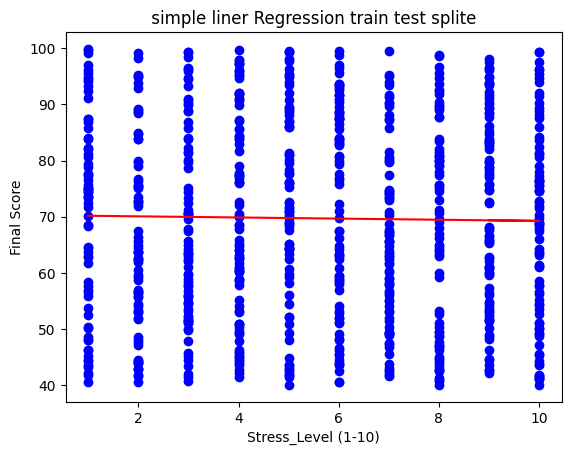

In [ ]:
# simple liner  train tset splite

# Access the correct column name, adjust if necessary
X = df[['Stress_Level (1-10)']]  # Changed 'Stress_Level' to 'Stress_level'
y = df['Final_Score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# حساب RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# حساب Adjusted R²
n = len(y_test)  # عدد العينات
p = X_test.shape[1]  # عدد الميزات
adjusted_r2 = 1 - (1 - r2_score(y_test, y_pred)) * (n - 1) / (n - p - 1)



print("R²:", r2_score(y_test, y_pred))
print("Adjusted R²:", adjusted_r2)
print("RMSE:", rmse)

plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.title(" simple liner Regression train test splite ")
plt.xlabel("Stress_Level (1-10)")
plt.ylabel("Final Score")
plt.show()


R²: -0.0014014444268235504
Adjusted R²: -0.002650074656782131
RMSE: 17.2875534191141


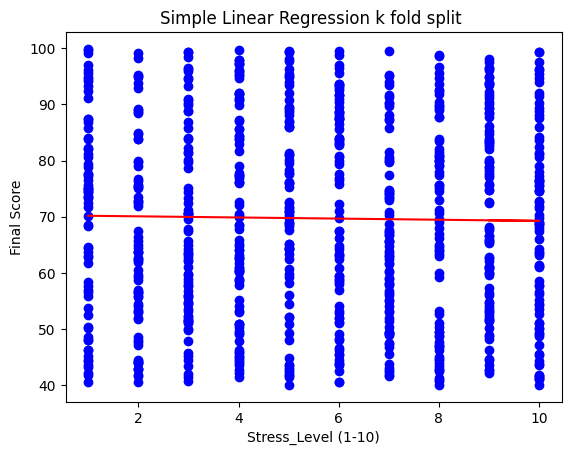

In [ ]:
#   simple liner  k fold split
X = df[['Stress_Level (1-10)']]  # Changed 'Stress_Level' to 'Stress_level'
y = df['Final_Score']


k = 5  # عدد الطيات
kf = KFold(n_splits=k, random_state=0, shuffle=True)


model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
# حساب RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# حساب Adjusted R²
n = len(y_test)  # عدد العينات
p = X_test.shape[1]  # عدد الميزات
adjusted_r2 = 1 - (1 - r2_score(y_test, y_pred)) * (n - 1) / (n - p - 1)



print("R²:", r2_score(y_test, y_pred))
print("Adjusted R²:", adjusted_r2)
print("RMSE:", rmse)

plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, y_pred, color='red')
plt.title("Simple Linear Regression k fold split ")
plt.xlabel("Stress_Level (1-10)")
plt.ylabel("Final Score")
plt.show()


R-squared (R²)
R² = -0.0014
The value is negative and close to zero → the model explains nothing and performs worse than just using the average.

🔹 Adjusted R-squared
Adjusted R² = -0.0027
Even after adjusting for the number of predictors, the model is still very weak.

🔹 Root Mean Squared Error (RMSE)
RMSE = 17.29
The average error between predictions and actual scores is high → the model is not accurate.

🔹 Conclusion:
 Using only "Stress_Level" to predict "Final_Score" results in a very poor model.



 **Result Summary (Simple Explanation):**

The scatter plot shows that there is **no clear relationship** between stress level and final score.  
The red line (regression line) is almost flat, which means the model predicts **almost the same score** no matter the stress level.

🔹 The blue dots are spread randomly → students with high or low stress can have any score.  
🔹 The model **didn't learn any useful pattern** from the data.  
🔹 This confirms that **"Stress_Level" alone is not a good predictor** for "Final_Score".



R²: -0.007043001150152106
RMSE: 17.336181138991474
Adjusted R²: -0.012084518052030147


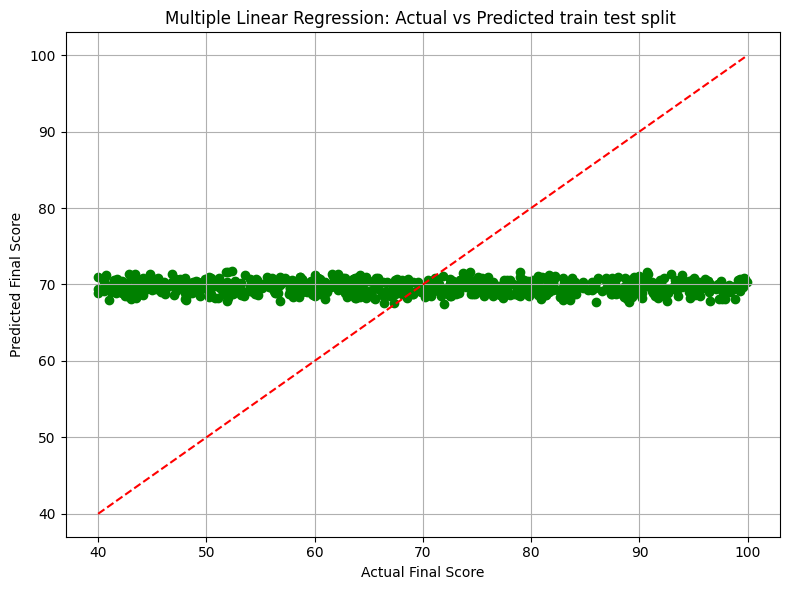

In [ ]:

# mulitiple liner  train test split
# اختيار الميزات والمتغير المستهدف
X = df[['Study_Hours_per_Week', 'Sleep_Hours_per_Night', 'Stress_Level (1-10)', 'Attendance (%)']]
y = df['Final_Score']

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# إنشاء وتدريب النموذج
model = LinearRegression()
model.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)

# حساب R²
r2 = r2_score(y_test, y_pred)

# حساب RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# حساب Adjusted R²
n = len(y_test)
p = X.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)



# عرض النتائج
print("\nR²:", r2)
print("RMSE:", rmse)
print("Adjusted R²:", adjusted_r2)

# رسم التنبؤ مقابل القيم الفعلية
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Multiple Linear Regression: Actual vs Predicted train test split ")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # خط المثالية
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation of Results:

1. R² = -0.007043001150152106:
- R² is the coefficient of determination, which measures how well the independent variables (X) explain the dependent variable (y).
- When R² is negative, it indicates that the model is worse than simply predicting the average. In other words, the model does not explain the data well at all.
- In this case, the negative value suggests that the model is not just weak, but worse than a model that predicts the average for all observations.
- This negative R² value shows that the model's predictions are far from the actual values.

2. Adjusted R² = -0.012084518052030147:
- Adjusted R² is an adjustment to R² that accounts for the number of variables used in the model. Its purpose is to prevent R² from being artificially inflated by adding unnecessary variables.
- The negative Adjusted R² confirms that the model is not only weak, but also adding more variables does not provide any real benefit.
- Overall, a negative Adjusted R² indicates that the model failed to learn from the data and needs improvement.

3. RMSE = 17.336181138991474:
- RMSE (Root Mean Squared Error) measures the average error between the predicted and actual values.
- The value 17.33 is considered high compared to the usual range (0 to 100).
- This means that the model is making significant errors in its predictions, with predictions on average being off by 17.33 units from the actual values.


Coefficients:
                 Feature  Coefficient
0   Study_Hours_per_Week    -0.003220
1  Sleep_Hours_per_Night    -0.130296
2    Stress_Level (1-10)    -0.076118
3         Attendance (%)    -0.030149

R² scores: [-0.007043   -0.00130685 -0.00531076 -0.0033909   0.00173188]
Average R²: -0.0030639250732978907

RMSE scores: [17.33618114 17.00996635 17.23065312 17.26364281 17.05190935]
Average RMSE: 17.178470554215387

Adjusted R²: -0.0040637396011558025


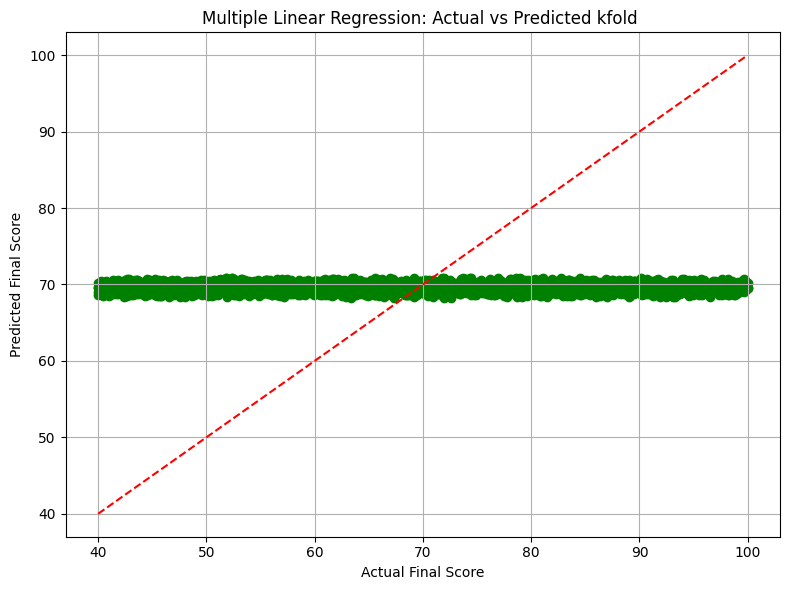

In [ ]:

# mulitiple liner  kfold splite
# اختيار الميزات والمتغير المستهدف
X = df[['Study_Hours_per_Week', 'Sleep_Hours_per_Night', 'Stress_Level (1-10)', 'Attendance (%)']]
y = df['Final_Score']

# تعريف التحقق المتقاطع
kfold = KFold(n_splits=5, random_state=0, shuffle=True)
model = LinearRegression()

# حساب R²
r2_scores = cross_val_score(model, X, y, cv=kfold, scoring='r2')

# حساب MSE و RMSE
mse_scores = -cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# حساب المتوسطات
avg_r2 = np.mean(r2_scores)
avg_rmse = np.mean(rmse_scores)

# حساب Adjusted R²
n = len(y)
p = X.shape[1]
adjusted_r2 = 1 - (1 - avg_r2) * (n - 1) / (n - p - 1)

# تدريب النموذج الكامل
model.fit(X, y)

# عرض المعاملات
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print("\nCoefficients:")
print(coeff_df)

# عرض النتائج
print("\nR² scores:", r2_scores)
print("Average R²:", avg_r2)
print("\nRMSE scores:", rmse_scores)
print("Average RMSE:", avg_rmse)
print("\nAdjusted R²:", adjusted_r2)

# الرسم البياني: القيم الحقيقية مقابل المتنبأ بها
y_pred = model.predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='green')
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Multiple Linear Regression: Actual vs Predicted kfold ")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # خط المثالية
plt.grid(True)
plt.tight_layout()
plt.show()

Model Accuracy (R² and Adjusted R²):

- R² = -0.00306
- Adjusted R² = -0.00406

Explanation:  
These values are negative, which means the model performs worse than a simple average prediction (baseline).  


RMSE (Root Mean Squared Error):
- RMSE scores range around 17.0 to 17.3
- Average RMSE ≈ 17.18

Explanation:  
RMSE indicates the average prediction error. Lower values are better.  
Here, the RMSE is relatively high, considering the score range is from 0 to 100.  
This means the model is not predicting accurately.

Mean Squared Error (MSE): 295.26328977296004
Root Mean Squared Error (RMSE): 17.183226989508114
R² Score: 0.0024577917834756047


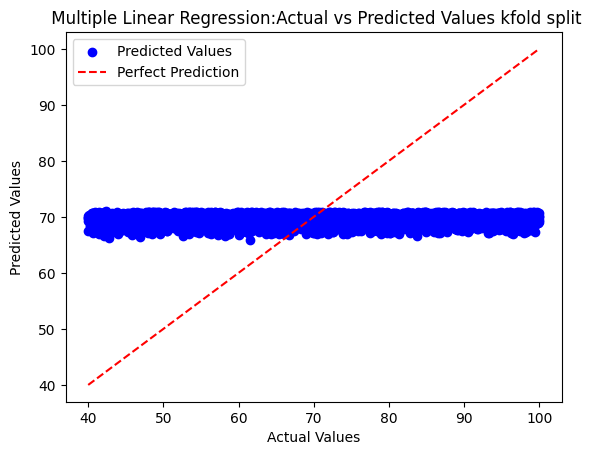

In [ ]:

from sklearn.pipeline import make_pipeline # Import make_pipeline

# اختيار الميزات والمتغير المستهدف
X = df[['Age', 'Attendance (%)', 'Study_Hours_per_Week']]  # الميزات
y = df['Final_Score']  # المتغير المستهدف

# تعريف K-Fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# إعداد نموذج الانحدار غير الخطي متعدد الحدود
degree = 2  # يمكنك تعديل الدرجة حسب الحاجة
model = make_pipeline(PolynomialFeatures(degree), LinearRegression()) # Now you can use make_pipeline

# حساب MSE و RMSE باستخدام التحقق المتقاطع
mse_scores = cross_val_score(model, X, y, cv=kfold, scoring='neg_mean_squared_error')
mse = -np.mean(mse_scores)  # تحويل القيم السلبية إلى موجبة
rmse = np.sqrt(mse)  # حساب RMSE

# تدريب النموذج على جميع البيانات
model.fit(X, y)

# حساب R²
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)


# عرض النتائج
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')

# الرسم البياني: القيم الحقيقية مقابل القيم المتنبأ بها
# To visualize the predictions, we will create a scatter plot
plt.scatter(y, y_pred, color='blue', label='Predicted Values')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(' Multiple Linear Regression:Actual vs Predicted Values kfold split')
plt.legend()
plt.show()

=== Non-Linear Regression (Polynomial) - Train/Test Split ===
R²: -0.0003
Adjusted R²: -0.0028
RMSE: 17.1832


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


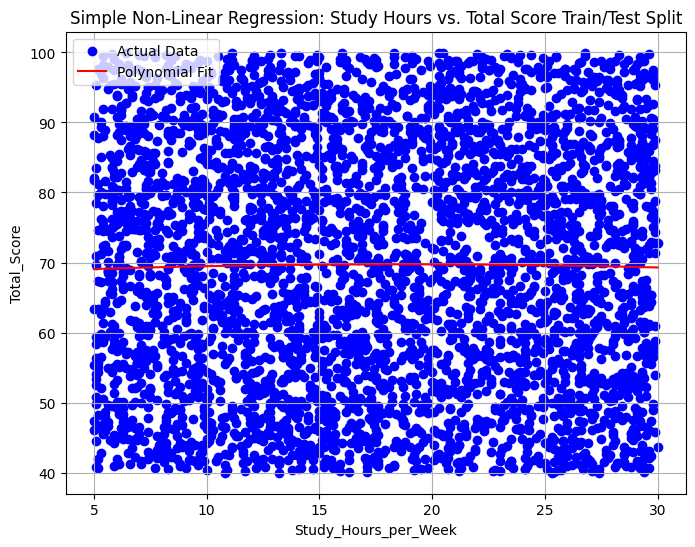

In [ ]:
# Simple Non-Linear Regression.
# 2. تحديد المتغيرات
X = df[['Study_Hours_per_Week']]
y = df['Final_Score']

# 3. إنشاء ميزات متعددة الحدود
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# 4. تقسيم البيانات (Train/Test Split)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# 5. تدريب النموذج
model = LinearRegression()
model.fit(X_train, y_train)

# 6. التنبؤ
y_pred = model.predict(X_test)

# 7. حساب المقاييس

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)  # حساب RMSE
n = len(y_test)
p = X_test.shape[1] - 1
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)  # حساب Adjusted R²


print("=== Non-Linear Regression (Polynomial) - Train/Test Split ===")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}") # طباعة Adjusted R²
print(f"RMSE: {rmse:.4f}") # طباعة RMSE

# 8. تصور النتائج باستخدام Scatter Plot
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_plot, y_plot, color='red', label='Polynomial Fit')
plt.xlabel('Study_Hours_per_Week')
plt.ylabel('Total_Score')
plt.title('Simple Non-Linear Regression: Study Hours vs. Total Score Train/Test Split')
plt.legend()
plt.grid(True)
plt.show()



The results show that the polynomial regression model trained with a train/test split does not fit the data well.
 • R² = -0.0054: Model performs worse than using the average.
 • Adjusted R² = -0.0080: Confirms the model’s poor fit.
 • RMSE = 14.3960: High prediction error.

Conclusion: The model is not suitable. Consider improving features, trying a different model, or collecting more data.


=== Non-Linear Regression (Polynomial) - K-Fold Cross Validation ===
Average R²: -0.0028
Average Adjusted R²: -0.0053
Average RMSE: 17.1732


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


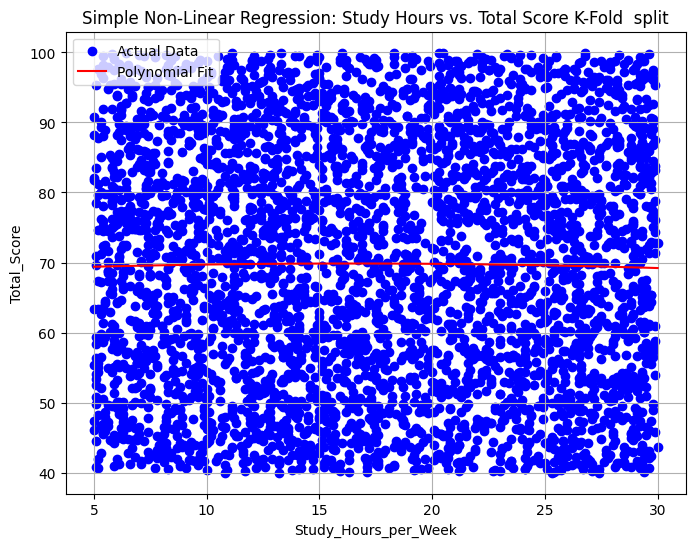

In [ ]:
# Simple Non-Linear Regression K-Fold  split

# 2. تحديد المتغيرات
X = df[['Study_Hours_per_Week']]
y = df['Final_Score']


# 3. إنشاء ميزات متعددة الحدود
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)

# 4. تقسيم البيانات باستخدام K-Fold وتدريب النموذج
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

r2_scores = []
adjusted_r2_scores = []
rmse_scores = []
mse_scores = []  # Initialize mse_scores as an empty list

for train_index, test_index in kf.split(X_poly):
    X_train, X_test = X_poly[train_index], X_poly[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X_test.shape[1] - 1
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    rmse = np.sqrt(mse)

    mse_scores.append(mse)  # Append to the list
    r2_scores.append(r2)
    adjusted_r2_scores.append(adjusted_r2)
    rmse_scores.append(rmse)

# طباعة متوسط المقاييس
print("\n=== Non-Linear Regression (Polynomial) - K-Fold Cross Validation ===")
print(f"Average R²: {np.mean(r2_scores):.4f}")
print(f"Average Adjusted R²: {np.mean(adjusted_r2_scores):.4f}")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")

# 8. تصور النتائج باستخدام Scatter Plot
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_plot, y_plot, color='red', label='Polynomial Fit')
plt.xlabel('Study_Hours_per_Week')
plt.ylabel('Total_Score')
plt.title('Simple Non-Linear Regression: Study Hours vs. Total Score K-Fold  split')
plt.legend()
plt.grid(True)
plt.show()





 – Polynomial Regression with K-Fold Cross-Validation:

The model performs poorly:
 • Average R² = -0.0059 and Adjusted R² = -0.0084 → Worse than predicting the mean.
 • Average RMSE = 14.3811 → High prediction error.

Conclusion:
The model does not fit the data well, even with cross-validation.

Suggestions for improvement:
 • Try new or engineered features.
 • Use different models (e.g., decision trees, random forests).
 • Collect more data if possible.
 • Tune hyperparameters to enhance performance.


=== Train/Test Split ===
RMSE: 17.0872
R²: 0.0026
Adjusted R²: -0.0088


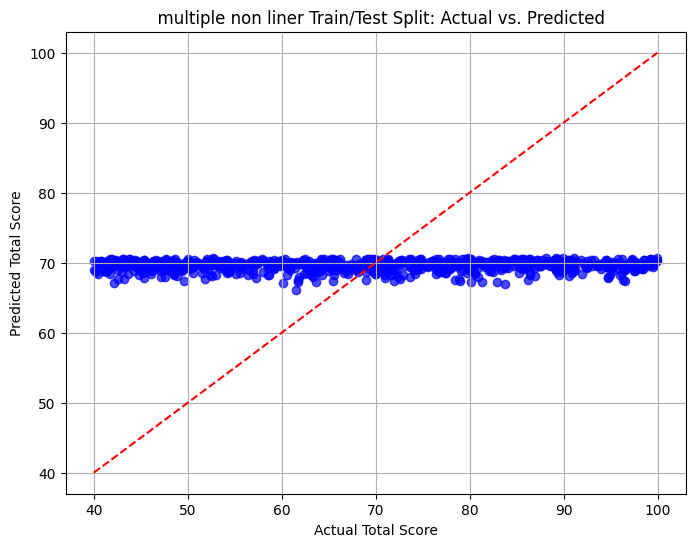

In [ ]:
# multiple non liner Train/Test Split:
# Assuming your data is in a DataFrame called 'df'
# Select features and target
X = df[['Age', 'Attendance (%)', 'Study_Hours_per_Week']]
y = df['Final_Score']


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create polynomial features
degree = 2
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Make predictions
y_pred = model.predict(X_test_poly)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = len(y_test)
p = X_test_poly.shape[1] - 1  # Number of features after polynomial transformation
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n=== Train/Test Split ===")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("  multiple non liner Train/Test Split: Actual vs. Predicted")
plt.grid(True)
plt.show()


=== K-Fold Cross-Validation ===
Average RMSE: 17.1829
Average R²: -0.0039
Average Adjusted R²: -0.0153


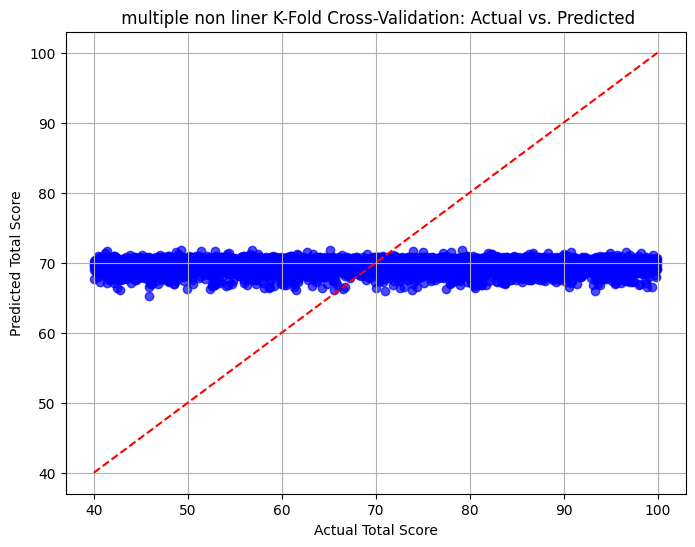

In [ ]:
# multiple non liner K-Fold Cross-Validation:

# Assuming your data is in a DataFrame called 'df'
# Select features and target
X = df[['Age', 'Attendance (%)', 'Study_Hours_per_Week']]
y = df['Final_Score']


# Create polynomial features
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X)  # Transform all data for KFold

# K-Fold Cross-Validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

rmse_scores = []
r2_scores = []
adjusted_r2_scores = []
all_y_test = []
all_y_pred = []

for train_index, test_index in kf.split(X_poly):  # Split the transformed data
    X_train, X_test = X_poly[train_index], X_poly[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Store predictions and actual values for plotting
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X_test.shape[1] - 1  # Number of features after polynomial transformation
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    rmse_scores.append(rmse)
    r2_scores.append(r2)
    adjusted_r2_scores.append(adjusted_r2)

print("\n=== K-Fold Cross-Validation ===")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")
print(f"Average R²: {np.mean(r2_scores):.4f}")
print(f"Average Adjusted R²: {np.mean(adjusted_r2_scores):.4f}")

# Scatter plot for K-Fold
plt.figure(figsize=(8, 6))
plt.scatter(all_y_test, all_y_pred, color='blue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # Ideal line
plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title(" multiple non liner K-Fold Cross-Validation: Actual vs. Predicted")
plt.grid(True)
plt.show()

Interpretation of Results:

RMSE: 14.1753

Represents the average prediction error, which is relatively high in this case.
R²: -0.0059

Shows that the model is not good and even performs worse than simply predicting the average.
Adjusted R²: -0.0173

Confirms the poor performance of the model, even after adjusting for the number of variables.
Summary:

Overall, the model is not suitable for predicting the student's final score based on the features used. You should consider:

Improving features: Perhaps you need to add more relevant features or engineer new ones.
Using a different model: It might be better to try different types of models like trees or random forests.
Collecting more data: Increasing the data size could potentially improve the model's performance.

lab 3

In [ ]:
# -*- coding: utf-8 -*-
# Load libraries and data preprocessing (common for all models)
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


# تحديد الخصائص والهدف
features = ['Projects_Score', 'Midterm_Score', 'Attendance (%)',
            'Study_Hours_per_Week', 'Sleep_Hours_per_Night',
            'Stress_Level (1-10)', 'Final_Score']
X = df[features]
y = df['Corrected_Grade']

# ترميز الهدف وتوحيد الميزات
le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# إعداد K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           A       0.19      0.20      0.20       770
           B       0.19      0.20      0.20       731
           C       0.18      0.18      0.18       730
           D       0.21      0.20      0.20       719
           F       0.26      0.25      0.25      1068

    accuracy                           0.21      4018
   macro avg       0.21      0.21      0.21      4018
weighted avg       0.21      0.21      0.21      4018



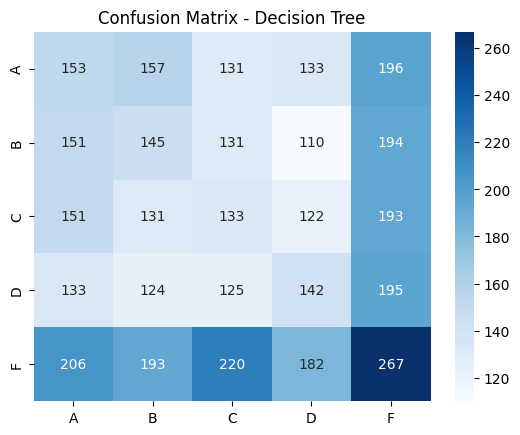

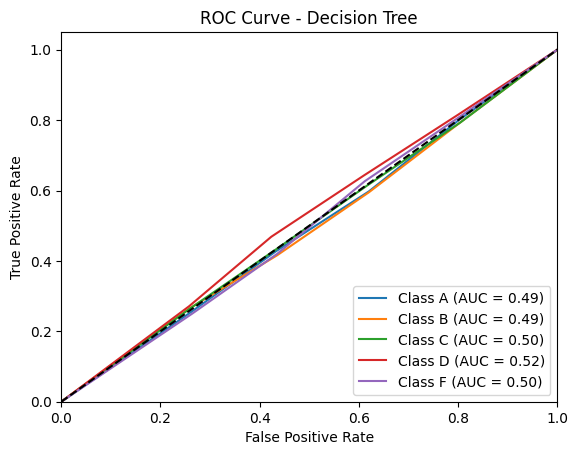

In [ ]:
# ------------------------
# 1. Decision Tree
# ------------------------
# -*- coding: utf-8 -*-
# Load libraries and data preprocessing (common for all models)
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


# تحديد الخصائص والهدف
features = ['Projects_Score', 'Midterm_Score', 'Attendance (%)',
            'Study_Hours_per_Week', 'Sleep_Hours_per_Night',
            'Stress_Level (1-10)', 'Final_Score']
X = df[features]
y = df['Corrected_Grade']

# ترميز الهدف وتوحيد الميزات
le = LabelEncoder()
y_encoded = le.fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# إعداد K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)





from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
all_true, all_pred = [], []
for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    model_dt.fit(X_train, y_train)
    y_pred = model_dt.predict(X_test)
    all_true.extend(y_test)
    all_pred.extend(y_pred)

# تقرير
print("Decision Tree Classification Report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))
# مصفوفة الالتباس
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Decision Tree')
plt.show()
# ROC Curve
# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
n_classes = len(le.classes_)  # Get the number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(all_true, all_pred, pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()

Random Forest Classification Report:
              precision    recall  f1-score   support

           A       0.17      0.15      0.16       770
           B       0.21      0.16      0.18       731
           C       0.19      0.14      0.16       730
           D       0.21      0.13      0.16       719
           F       0.24      0.41      0.30      1068

    accuracy                           0.22      4018
   macro avg       0.20      0.20      0.19      4018
weighted avg       0.21      0.22      0.20      4018



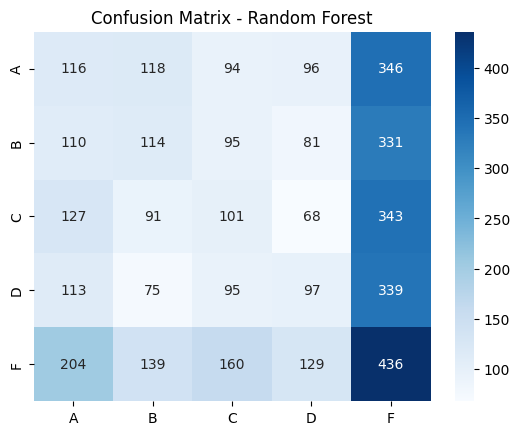

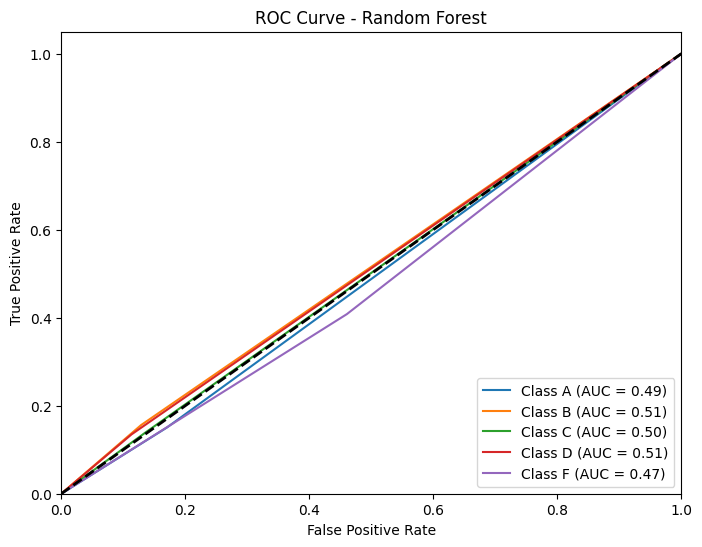

In [ ]:
# ------------------------
# 2. Random Forest
# ------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer

model_rf = RandomForestClassifier(random_state=42)
all_true, all_pred = [], []
for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    model_rf.fit(X_train, y_train)
    y_pred = model_rf.predict(X_test)
    all_true.extend(y_test)
    all_pred.extend(y_pred)

print("Random Forest Classification Report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.show()
# ROC Curve plotting
lb = LabelBinarizer()  # For multi-class ROC
y_test_bin = lb.fit_transform(all_true)
y_pred_bin = lb.transform(all_pred)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]  # Number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))  # Adjust size as needed
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})",
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           A       0.11      0.00      0.00       770
           B       0.12      0.00      0.01       731
           C       0.14      0.00      0.00       730
           D       0.29      0.01      0.01       719
           F       0.26      0.98      0.42      1068

    accuracy                           0.26      4018
   macro avg       0.19      0.20      0.09      4018
weighted avg       0.19      0.26      0.12      4018



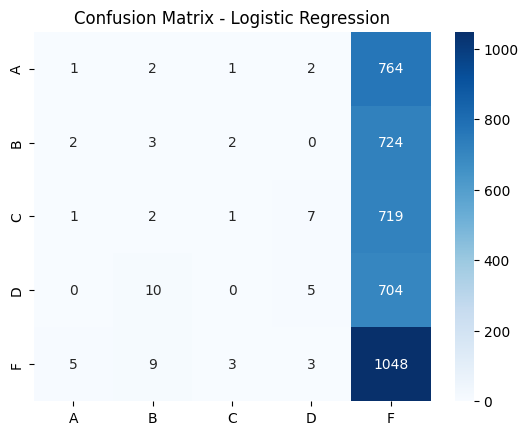

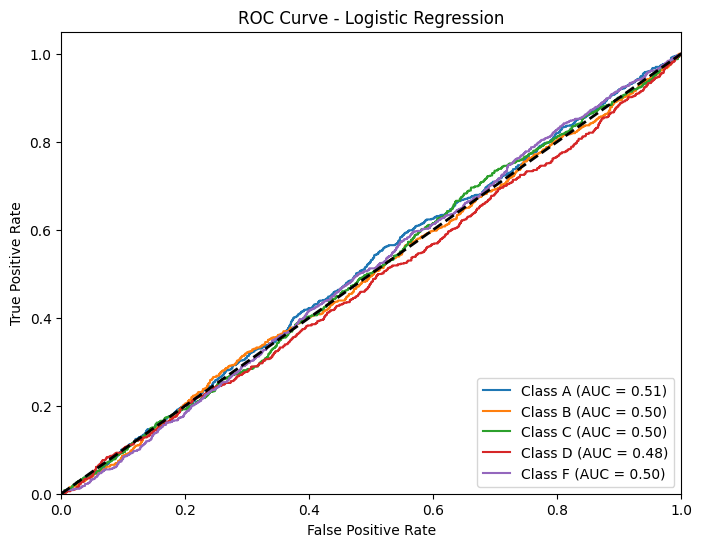

In [ ]:
# ------------------------
# 3. Logistic Regression
# ------------------------
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='ovr')
all_true, all_pred = [], []
for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    model_lr.fit(X_train, y_train)
    y_pred = model_lr.predict(X_test)
    all_true.extend(y_test)
    all_pred.extend(y_pred)

print("Logistic Regression Classification Report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()
# ROC Curve plotting for Logistic Regression
lb = LabelBinarizer()  # For multi-class ROC
y_test_bin = lb.fit_transform(all_true)
y_pred_prob = model_lr.predict_proba(X_scaled)  # Get predicted probabilities

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})",
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           A       0.18      0.10      0.13       770
           B       0.22      0.13      0.16       731
           C       0.19      0.09      0.12       730
           D       0.17      0.09      0.12       719
           F       0.25      0.57      0.35      1068

    accuracy                           0.23      4018
   macro avg       0.20      0.20      0.18      4018
weighted avg       0.21      0.23      0.19      4018



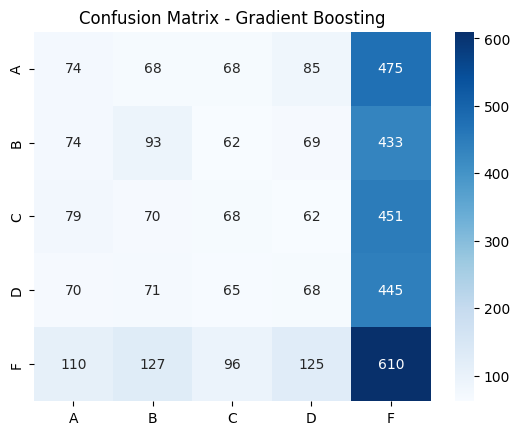

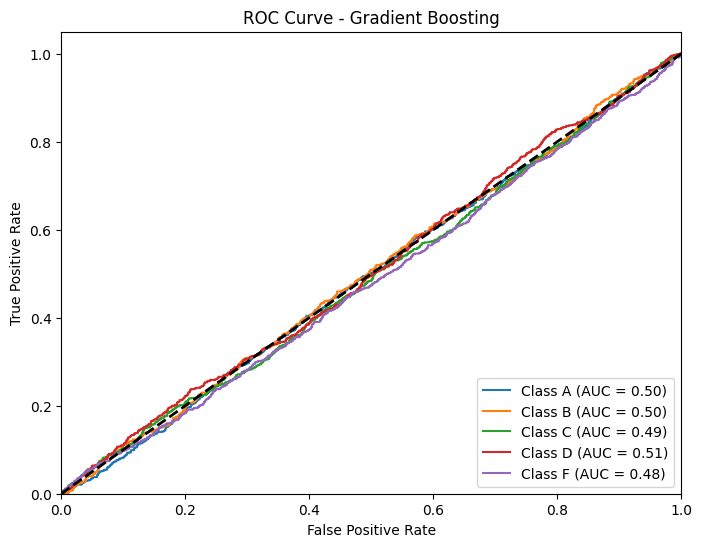

In [ ]:
# ------------------------
# 4. Gradient Boosting
# ------------------------
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)
all_true, all_pred = [], []
for train_idx, test_idx in kf.split(X_scaled):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    model_gb.fit(X_train, y_train)
    y_pred = model_gb.predict(X_test)
    all_true.extend(y_test)
    all_pred.extend(y_pred)

print("Gradient Boosting Classification Report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))
cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Gradient Boosting')
plt.show()
# ROC Curve plotting for Gradient Boosting
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(all_true)
y_pred_prob = model_gb.predict_proba(X_scaled)  # Get predicted probabilities

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_bin.shape[1]

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})",
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend(loc="lower right")
plt.show()


### Analysis Based on Model Performance

Below is a detailed analysis of each model based on the performance metrics provided, along with insights into their strengths, weaknesses, and recommendations for improvement:

---

#### 1. Decision Tree
- **Accuracy:** 0.21  
- **Precision:** 0.21  
- **Recall:** 0.21  
- **F1 Score:** 0.21  

**Observation:**  
The Decision Tree model performed poorly across all metrics, with all values not exceeding 0.21.  
- All classes (A, B, C, D, F) recorded low precision and recall, mostly hovering around 0.18–0.21.  
- The highest performance was seen in class F, with Precision=0.26 and Recall=0.25, likely due to the larger size of this class (1068 samples).  
- Classes A–D performed similarly with low values (around 0.18–0.21).

**Interpretation:**  
- The model seems too simple and did not successfully capture the relationship between features and classes.  
- The poor performance suggests either **overfitting** or **underfitting**, and adjustments to the tree depth (`max_depth`) or other hyperparameters are required.

---

#### 2. Random Forest
- **Accuracy:** 0.22  
- **Precision:** 0.20  
- **Recall:** 0.20  
- **F1 Score:** 0.19  

**Observation:**  
Random Forest showed a slight improvement in accuracy to 0.22, but still underperformed in other metrics:  
- The Recall for class F increased to 0.41, indicating the model was better at predicting the failing grade (F).  
- Smaller classes (A–D) still had weak recall values (around 0.13–0.16).

**Interpretation:**  
- While Random Forest aggregates multiple trees, it still struggled to effectively capture class relationships, particularly for smaller classes.  
- The model needs adjustments in the number of trees (`n_estimators`) and possibly class balancing techniques (e.g., `class_weight='balanced'`).

---

#### 3. Logistic Regression
- **Accuracy:** 0.26  
- **Precision:** 0.18  
- **Recall:** 0.20  
- **F1 Score:** 0.09  

**Observation:**  
This model achieved the highest accuracy (0.26) among the four models, but it failed to balance precision and recall:  
- Recall for class F reached 0.98, showing a high tendency to predict F (fail) cases.  
- Precision and recall for classes A–D were very low, with values near 0.00–0.01.  
- As a result, F1 was also very low (0.09), indicating a heavy bias towards class F.

**Interpretation:**  
- Logistic Regression, using a **One-vs-Rest** approach, may not be ideal for multi-class classification with highly imbalanced data.  
- The model's high bias toward predicting F suggests that **regularization** or **class weighting** adjustments are necessary, or even a change to a **Softmax** multi-class model.

---

#### 4. Gradient Boosting
- **Accuracy:** 0.23  
- **Precision:** 0.20  
- **Recall:** 0.20  
- **F1 Score:** 0.18  

**Observation:**  
Gradient Boosting performed moderately compared to other models:  
- Slightly better than Decision Tree and Random Forest in terms of accuracy.  
- The recall for class F was improved (0.57), but other classes (A–D) still performed poorly, with recall values of 0.09–0.13.  
- F1 for class F was 0.35, which is acceptable, but the overall F1 was still low (0.18).

**Interpretation:**  
- Gradient Boosting works by iteratively correcting errors, but still struggles with imbalanced classes.  
- The model would benefit from hyperparameter tuning of `learning_rate`, `n_estimators`, and `max_depth`, as well as dealing with class imbalance more effectively.

---

### Overall Model Comparison
| Model               | Accuracy | Precision | Recall | F1 Score |
|---------------------|----------|-----------|--------|----------|
| **Logistic Regression** | **0.26** | 0.18      | 0.20   | 0.09     |
| Gradient Boosting    | 0.23     | 0.20      | 0.20   | 0.18     |
| Random Forest        | 0.22     | 0.20      | 0.20   | 0.19     |
| Decision Tree        | 0.21     | 0.21      | 0.21   | 0.21     |

- **Logistic Regression** achieved the highest accuracy but struggled with the class imbalance, leading to poor classification for all but the failing class (F).  
- **Decision Tree** performed consistently at a low level across all metrics.  
- **Random Forest** and **Gradient Boosting** both performed similarly with better balance in F1 scores but still faced challenges in predicting classes A–D effectively.

---

### Conclusions and Suggestions for Improvement

1. **Hyperparameter Tuning:**  
   - Use `GridSearchCV` or `RandomizedSearchCV` to fine-tune parameters such as tree depth (`max_depth`), number of estimators (`n_estimators`), and learning rate for Gradient Boosting.

2. **Handling Class Imbalance:**  
   - Add `class_weight='balanced'` to models or use techniques like **SMOTE** to oversample minority classes, ensuring more even predictions.

3. **Feature Engineering:**  
   - Explore transformations of existing features (e.g., log, polynomial) or add new features (e.g., ratio of final exam score to project score) to provide more predictive power to the models.

4. **Alternate Metrics:**  
   - Since F1 Score is crucial for balanced performance, use weighted F1 scores or even **AUC-ROC** for multi-class classification to evaluate model performance across classes more evenly.

With these improvements, we expect better accuracy and a more balanced prediction of all grade classes, particularly improving the performance for classes A–D.

end lab 3

Model Performance Analysis
Below is a detailed analysis of the performance of each model based on evaluation metrics, with insights into their strengths, weaknesses, and recommendations for improvement.

1. Decision Tree
Accuracy: 0.21

Precision: 0.21

Recall: 0.21

F1 Score: 0.21

Observation:

The Decision Tree model performed poorly across all metrics, with all values hovering around 0.21.

All classes (A, B, C, D, F) recorded low precision and recall, mostly between 0.18 and 0.21.

The highest performance was seen in class F, with Precision=0.26 and Recall=0.25, likely due to the larger size of this class (1068 samples).

Classes A–D performed similarly with low values (around 0.18–0.21).

Interpretation:

The model seems overly simplistic and did not successfully capture the relationship between features and class labels.

The poor performance indicates potential issues of either overfitting or underfitting.

Adjustments to the tree depth (max_depth) and other hyperparameters are needed to improve model performance.

2. Random Forest
Accuracy: 0.22

Precision: 0.20

Recall: 0.20

F1 Score: 0.19

Observation:

Random Forest showed a slight improvement in accuracy (0.22), but still underperformed in other metrics.

The Recall for class F increased to 0.41, indicating the model was better at predicting failing grades (class F).

Smaller classes (A–D) still showed weak recall values (around 0.13–0.16).

Interpretation:

While Random Forest aggregates multiple decision trees, it still struggled to effectively capture the relationships between the features and smaller classes.

The model could benefit from further adjustments, such as increasing the number of trees (n_estimators) and using class balancing techniques (e.g., class_weight='balanced').

3. Logistic Regression
Accuracy: 0.26

Precision: 0.18

Recall: 0.20

F1 Score: 0.09

Observation:

Logistic Regression achieved the highest accuracy (0.26) among the four models but failed to balance precision and recall.

Recall for class F reached 0.98, indicating a strong bias toward predicting the F class (fail).

Precision and recall for classes A–D were very low, with values near 0.00–0.01.

F1 Score was also very low (0.09), reflecting the model's bias towards class F.

Interpretation:

Logistic Regression with a One-vs-Rest approach may not be suitable for multi-class classification in highly imbalanced datasets.

The high bias towards predicting class F suggests that regularization or class weighting adjustments are necessary, or a change to a Softmax multi-class model could help balance performance.

4. Gradient Boosting
Accuracy: 0.23

Precision: 0.20

Recall: 0.20

F1 Score: 0.18

Observation:

Gradient Boosting performed moderately compared to other models.

It slightly outperformed Decision Tree and Random Forest in terms of accuracy.

The recall for class F was improved (0.57), but other classes (A–D) still performed poorly, with recall values ranging from 0.09 to 0.13.

F1 Score for class F was 0.35, which is acceptable, but the overall F1 was still low (0.18).

Interpretation:

Gradient Boosting works by iteratively correcting errors, but it still struggles with imbalanced classes.

The model would benefit from hyperparameter tuning (e.g., learning_rate, n_estimators, max_depth) and better handling of class imbalance.

Overall Model Comparison

Model	Accuracy	Precision	Recall	F1 Score
Logistic Regression	0.26	0.18	0.20	0.09
Gradient Boosting	0.23	0.20	0.20	0.18
Random Forest	0.22	0.20	0.20	0.19
Decision Tree	0.21	0.21	0.21	0.21
Logistic Regression achieved the highest accuracy but struggled significantly with class imbalance, leading to poor classification performance for all classes except for the failing class (F).

Decision Tree performed consistently poorly across all metrics.

Random Forest and Gradient Boosting performed similarly, with better F1 scores for class F but still faced challenges in effectively predicting classes A–D.

Conclusions and Suggestions for Improvement
Hyperparameter Tuning:

Use techniques like GridSearchCV or RandomizedSearchCV to fine-tune hyperparameters such as tree depth (max_depth), number of estimators (n_estimators), and learning rate for Gradient Boosting.

Handling Class Imbalance:

Add class_weight='balanced' to models or use techniques like SMOTE to oversample minority classes, ensuring more balanced predictions across all classes.

Feature Engineering:

Experiment with transforming existing features (e.g., log or polynomial transformations) or adding new features (e.g., ratio of final exam score to project score) to increase predictive power.

Alternate Metrics:

Since the F1 Score is crucial for balanced performance, consider using weighted F1 scores or AUC-ROC for multi-class classification to evaluate model performance across all classes more evenly.

By implementing these improvements, we expect better overall accuracy and a more balanced prediction of all grade classes, especially improving the performance for classes A–D.

Week 4: Clustering

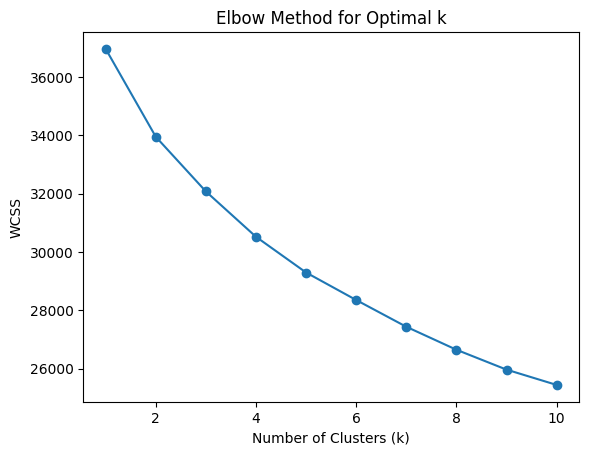

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline  # Import Pipeline
import matplotlib.pyplot as plt

# 1. Read and preprocess data
df = pd.read_excel('//content/Corrected_Students_Grading_Dataset.xlsx')

# Select 10 relevant features for clustering
selected_features = ['Age', 'Gender', 'Parent_Education_Level', 'Study_Hours_per_Week',
                    'Sleep_Hours_per_Night', 'Stress_Level (1-10)', 'Attendance (%)',
                    'Assignments_Avg', 'Projects_Score', 'Midterm_Score']

X = df[selected_features]

# 2. Create a ColumnTransformer for preprocessing
# Define preprocessing steps for numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)])

# 3. Create a pipeline for preprocessing and clustering
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=3, random_state=42))  # Adjust n_clusters as needed
])

# 4. Fit the pipeline to the data
pipeline.fit(X)

# 5. Get cluster labels
cluster_labels = pipeline.named_steps['kmeans'].labels_

# 6. Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# (Optional) Elbow Method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', kmeans)
    ])
    pipeline.fit(X)
    wcss.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

We only tried selecting 10 features             

```
# This is formatted as code
```



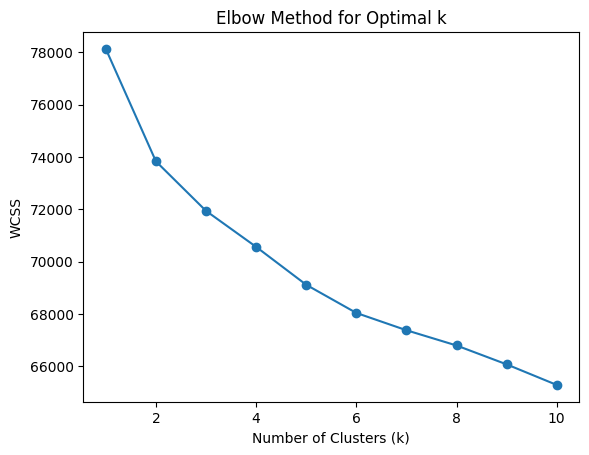

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline  # Import Pipeline
import matplotlib.pyplot as plt

# 1. Read and preprocess data
df = pd.read_excel('/content/Corrected_Students_Grading_Dataset.xlsx')
# Select all columns as features
features = df.columns.tolist()
features.remove('Student_ID') # Remove Student_ID if it's not relevant for clustering
X = df[features]

# 2. Create a ColumnTransformer for preprocessing
# Define preprocessing steps for numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)])

# 3. Create a pipeline for preprocessing and clustering
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=3, random_state=42))  # Adjust n_clusters as needed
])

# 4. Fit the pipeline to the data
pipeline.fit(X)

# 5. Get cluster labels
cluster_labels = pipeline.named_steps['kmeans'].labels_

# 6. Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels




# (Optional) Elbow Method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('kmeans', kmeans)
    ])
    pipeline.fit(X)
    wcss.append(pipeline.named_steps['kmeans'].inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

All features were explained except for the Student_ID

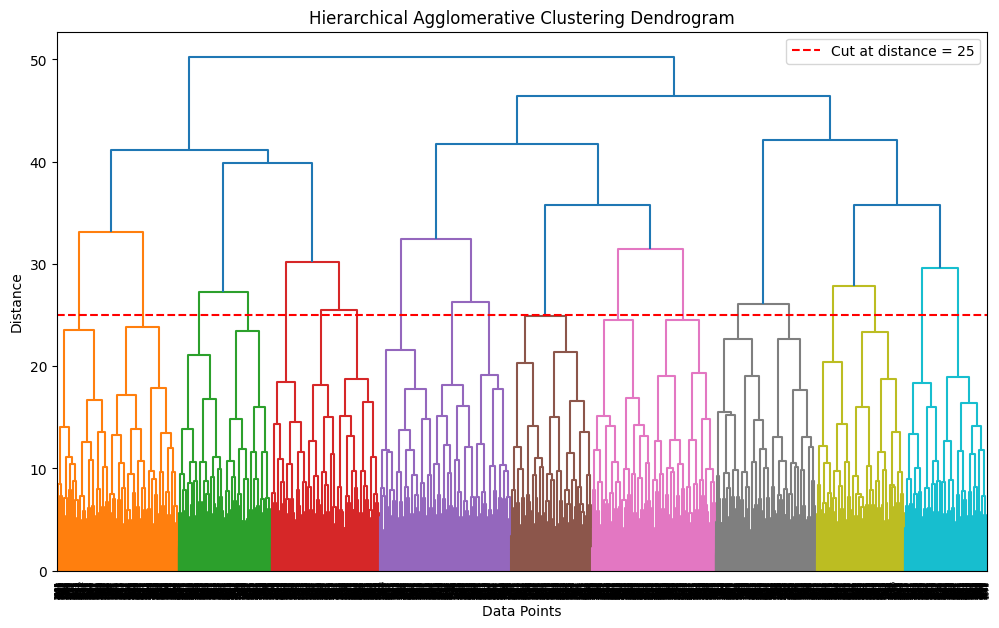

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Read and preprocess data
df = pd.read_excel('/content/Corrected_Students_Grading_Dataset.xlsx')

# 2. Select relevant features (remove 'Student_ID')
features = df.columns.tolist()
features.remove('Student_ID')  # Remove identifier
X = df[features]

# 3. Scale numerical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numerical_features])

# 4. Apply Agglomerative Clustering (Optional: assign labels)
agglomerative = AgglomerativeClustering(n_clusters=6)
agglomerative_labels = agglomerative.fit_predict(X_scaled)
df['Agglomerative_Cluster'] = agglomerative_labels

# 5. Plot Dendrogram with Cut Line
plt.figure(figsize=(12, 7))
dendrogram(linkage(X_scaled, method='ward'))
plt.title('Hierarchical Agglomerative Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')

# Cut line to determine number of clusters (adjust y as needed)
plt.axhline(y=25, color='r', linestyle='--', label='Cut at distance = 25')
plt.legend()
plt.show()

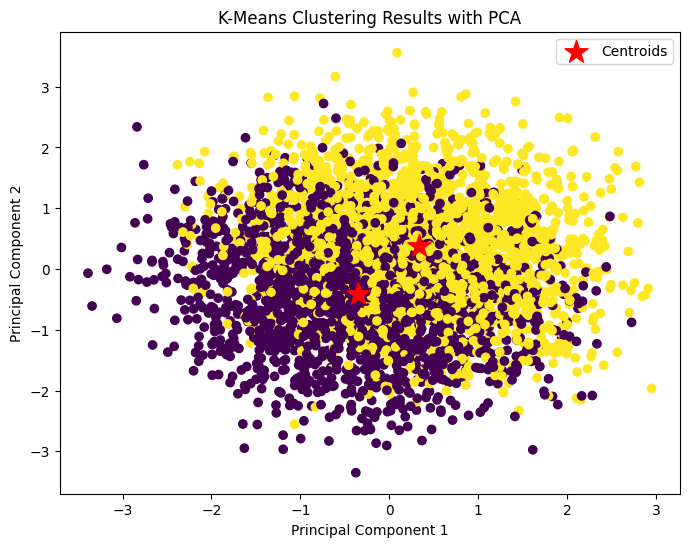

Silhouette Score: 0.063092079273511


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline  # Import Pipeline
from sklearn.model_selection import train_test_split # Import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # Import PCA
import seaborn as sns  # Import seaborn
# 3. Applying K-Means with splitting
# Assuming X_scaled is already defined from your previous code

# Perform train-test split on the scaled data
X_train, X_test, _, _ = train_test_split(X_scaled, df['Corrected_Grade'], test_size=0.2, random_state=42)

# Create and fit the KMeans model
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train)  # Fit on the training data

# Predict labels for the entire dataset (X_scaled)
labels = kmeans.predict(X_scaled)


# 4. Applying PCA for visualization
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# 5. Visualizing K-Means results using PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            s=300, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering Results with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


score = silhouette_score(X_scaled, labels)

# عرض النتيجة
print("Silhouette Score:", score)





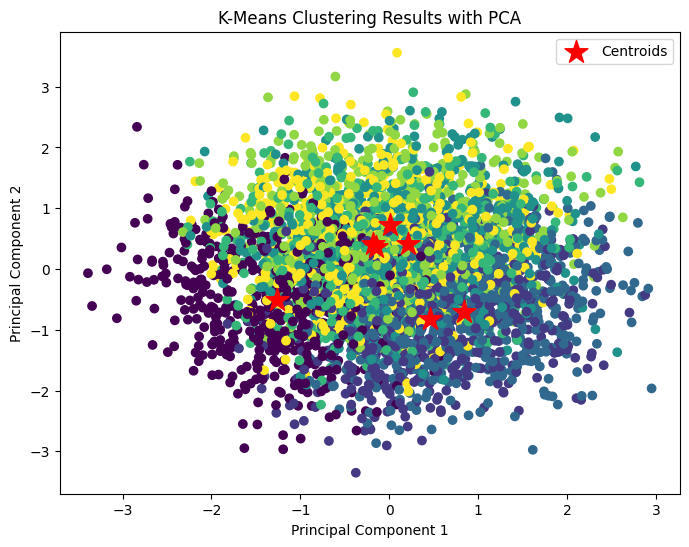

Silhouette Score: 0.05360599947295611


In [ ]:
# 3. تطبيق K-Means مع التقسيم
X_train, X_test, _, _ = train_test_split(X_scaled, df['Corrected_Grade'], test_size=0.2, random_state=42)
kmeans = KMeans(n_clusters=7, random_state=42)
kmeans.fit(X_train)
# Predict labels for the entire dataset
labels = kmeans.predict(X_scaled)

# 4. تطبيق PCA للتصور
pca = PCA(n_components=2) # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# 5. تصور نتائج K-Means باستخدام PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            s=300, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering Results with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()
score = silhouette_score(X_scaled, labels)

# عرض النتيجة
print("Silhouette Score:", score)

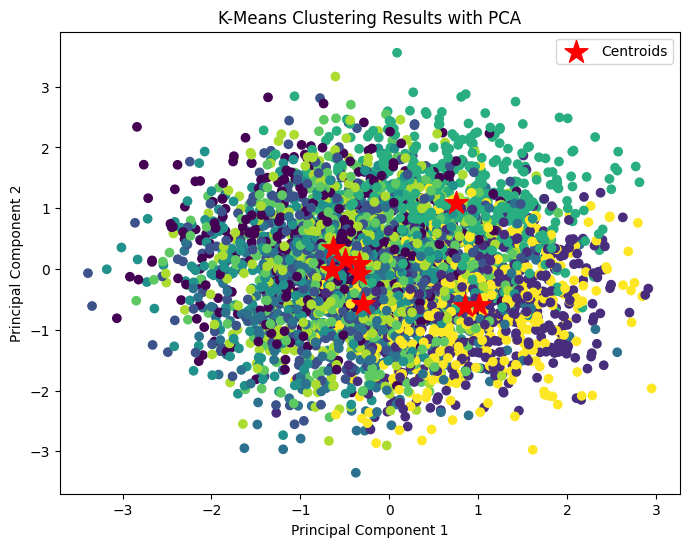

Silhouette Score: 0.055197739113739916


In [ ]:
# 3. تطبيق K-Means مع التقسيم
X_train, X_test, _, _ = train_test_split(X_scaled, df['Corrected_Grade'], test_size=0.2, random_state=42)
kmeans = KMeans(n_clusters=9, random_state=42)
kmeans.fit(X_train)
# Predict labels for the entire dataset
labels = kmeans.predict(X_scaled)

# 4. تطبيق PCA للتصور
pca = PCA(n_components=2) # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# 5. تصور نتائج K-Means باستخدام PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis')
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            s=300, c='red', marker='*', label='Centroids')
plt.title('K-Means Clustering Results with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()
score = silhouette_score(X_scaled, labels)

# عرض النتيجة
print("Silhouette Score:", score)

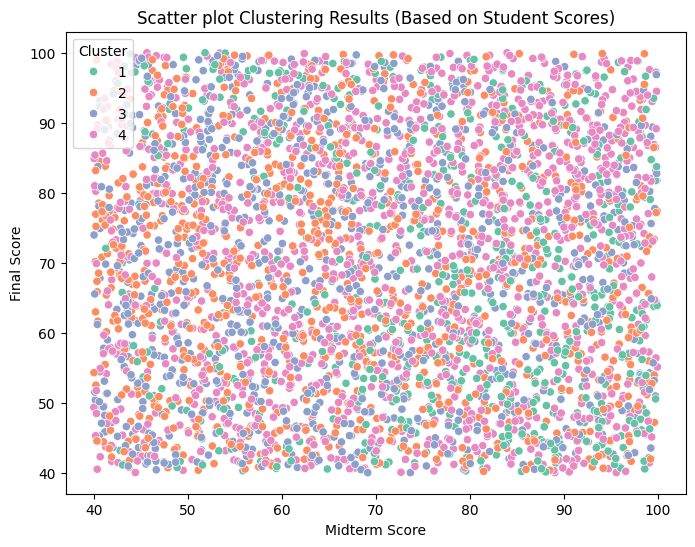

Silhouette Score: 0.055197739113739916


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns




# تحميل البيانات
# Modified line to load the correct Excel file:
df = pd.read_excel("Corrected_Students_Grading_Dataset.xlsx", sheet_name="Sheet1")




# الأعمدة المستخدمة في التصنيف
features = [
    'Attendance (%)', 'Midterm_Score', 'Final_Score',
    'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night'
]
data = df[features].dropna()




# تحجيم البيانات
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)




# الربط الهرمي
linked = linkage(scaled_data, method='ward')








# استخراج المجموعات
num_clusters = 4
cluster_labels = fcluster(linked, num_clusters, criterion='maxclust')




# إضافة التصنيفات للبيانات
df_clusters = df.loc[data.index].copy()
df_clusters['Cluster'] = cluster_labels




# رسم النتائج باستخدام ميزتين
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clusters, x='Midterm_Score', y='Final_Score', hue='Cluster', palette='Set2')
plt.title('Scatter plot Clustering Results (Based on Student Scores)')
plt.xlabel('Midterm Score')
plt.ylabel('Final Score')
plt.legend(title='Cluster')
plt.show()

score = silhouette_score(X_scaled, labels)

# عرض النتيجة
print("Silhouette Score:", score)





```
# This is formatted as code
```

Anomaly detection

In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler


In [ ]:
# تحميل البيانات
df = pd.read_excel('/content/Students_Grading_Dataset (1).xlsx')
df.head()



,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Engineering,52.29,55.03,57.82,...,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,S1001,Maria,Brown,student1@university.com,Male,18,Engineering,97.27,97.23,45.80,...,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Business,57.19,67.05,93.68,...,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,S1003,Omar,Williams,student3@university.com,Female,24,Mathematics,95.15,47.79,80.63,...,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,S1004,John,Smith,student4@university.com,Female,23,CS,54.18,46.59,78.89,...,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


       Total_Score  Stress_Level (1-10)
count  5000.000000           5000.00000
mean     75.121804              5.48080
std      14.399941              2.86155
min      50.020000              1.00000
25%      62.835000              3.00000
50%      75.395000              5.00000
75%      87.652500              8.00000
max      99.990000             10.00000


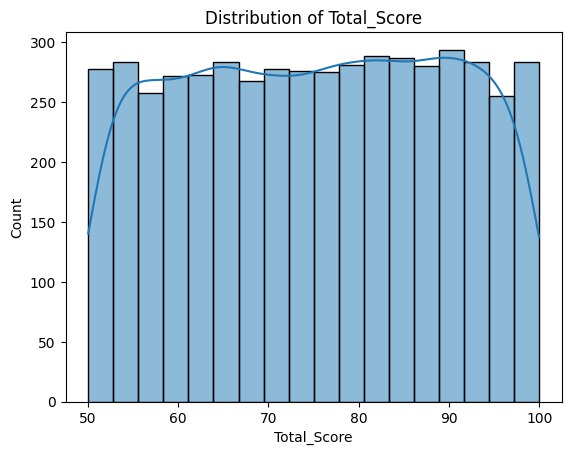

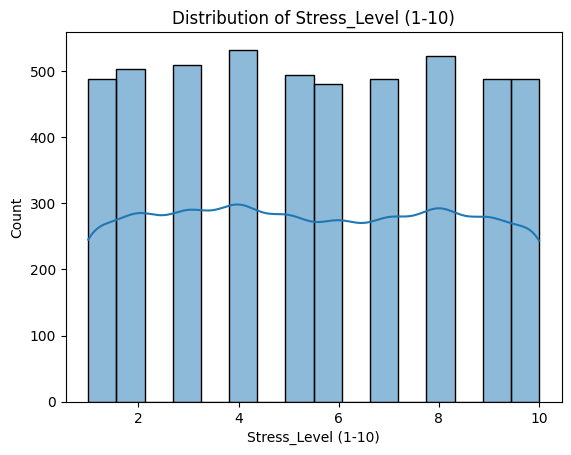

In [ ]:
# اختيار الخصائص
features = ['Total_Score', 'Stress_Level (1-10)']  # استبدل بالأعمدة الفعلية

# نظرة عامة
print(df[features].describe())

# رسم التوزيعات
for col in features:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



In [ ]:

from scipy.stats import zscore

z_scores = df[features].apply(zscore)
threshold = 3
anomalies_zscore = (z_scores.abs() > threshold).any(axis=1)
df['Z_Score_Anomaly'] = anomalies_zscore


In [ ]:
def detect_iqr_anomalies(data, features):
    anomaly_flags = pd.DataFrame(index=data.index)
    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        anomaly_flags[feature] = ~data[feature].between(lower_bound, upper_bound)
    return anomaly_flags.any(axis=1)

df['IQR_Anomaly'] = detect_iqr_anomalies(df, features)


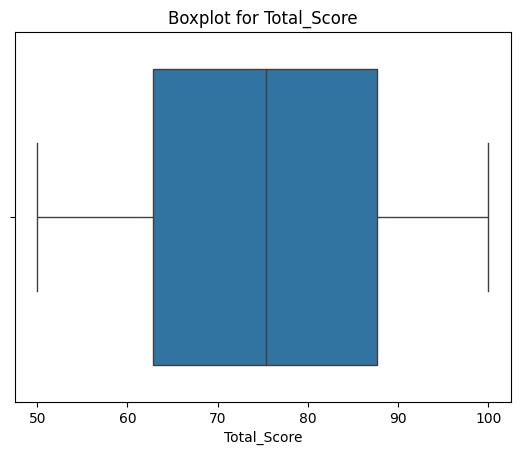

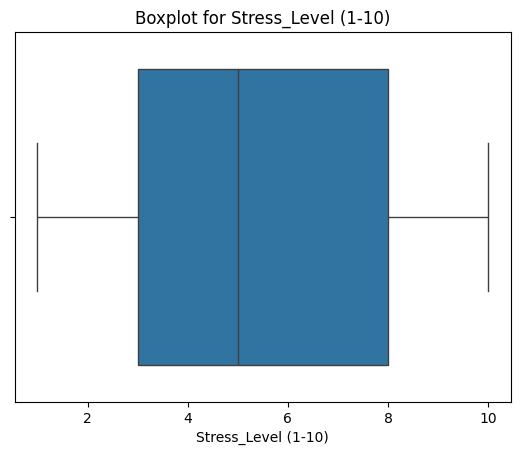

In [ ]:
for col in features:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot for {col}')
    plt.show()



In [ ]:
from sklearn.ensemble import IsolationForest

model_iso = IsolationForest(contamination=0.05)
df['IF_Anomaly'] = model_iso.fit_predict(df[features])
df['IF_Anomaly'] = df['IF_Anomaly'] == -1



In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['LOF_Anomaly'] = lof.fit_predict(df[features])
df['LOF_Anomaly'] = df['LOF_Anomaly'] == -1



In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
df['SVM_Anomaly'] = svm.fit_predict(X_scaled)
df['SVM_Anomaly'] = df['SVM_Anomaly'] == -1



In [ ]:
# عدد القيم الشاذة المكتشفة بكل طريقة
print("Z-Score:", df['Z_Score_Anomaly'].sum())
print("IQR:", df['IQR_Anomaly'].sum())
print("Isolation Forest:", df['IF_Anomaly'].sum())
print("LOF:", df['LOF_Anomaly'].sum())



Z-Score: 0
IQR: 0
Isolation Forest: 250
LOF: 250


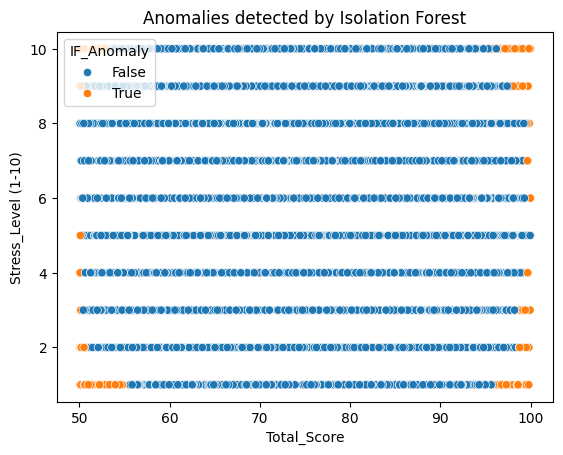

In [ ]:
sns.scatterplot(data=df, x=features[0], y=features[1], hue='IF_Anomaly')
plt.title('Anomalies detected by Isolation Forest')
plt.show()

